credit_score\
num_credit_cards\
has_chip\
num_cards_issued

months_to_expire\
is_credit\
is_prepaid

cb_Visa\
cb_Mastercard\
cb_Amex\
cb_Discover

months_from_account\
years_since_pin_change\
years_to_retirement 

In [2]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.metrics import average_precision_score

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score, 
    precision_recall_curve,
    classification_report
)
pd.set_option("display.max_rows", None)
from statsmodels.tools.sm_exceptions import PerfectSeparationError

TARGET = "fraud"

%matplotlib inline

In [3]:
df = pd.read_parquet("../5DATA/dataset/train_stage2")

In [4]:
BASELINE = [
    # 거래 강도
    "log_abs_amount",
    "amount_income_ratio",
    "amount_limit_ratio",

    # 에러
    "has_error",

    # 고객 맥락 최소
    "credit_limit",
    "current_age",

    # 카드 특성
    "is_credit",
    "has_chip",
]

### Credit Risk Layer

**credit_score**

In [5]:
col = "credit_score"

s = pd.to_numeric(df[col], errors="coerce")

summary = pd.DataFrame({
    "count": [s.notna().sum()],
    "missing_rate": [s.isna().mean()],
    "mean": [s.mean()],
    "std": [s.std()],
    "skew": [s.skew()],
    "p01": [s.quantile(0.01)],
    "p50": [s.quantile(0.50)],
    "p99": [s.quantile(0.99)],
    "min": [s.min()],
    "max": [s.max()],
})

summary

,count,missing_rate,mean,std,skew,p01,p50,p99,min,max
0,608430,0.0,709.295457,71.234803,-0.431512,508.0,710.0,850.0,488,850


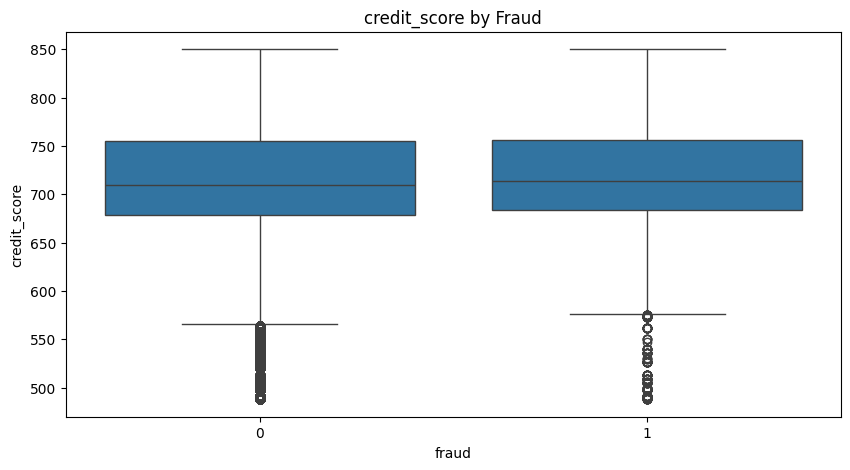

In [6]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="fraud",
    y="credit_score"
)

plt.title("credit_score by Fraud")
plt.show()

> fraud에 따른 큰 차이 없음

In [7]:
base = df["fraud"].mean()

tmp = df[[col, "fraud"]].dropna().copy()
tmp["bin"] = pd.qcut(tmp[col], 10, duplicates="drop")

g = tmp.groupby("bin")["fraud"]

credit_score_lift = pd.DataFrame({
    "count": g.size(),
    "fraud_rate": g.mean(),
})

credit_score_lift["lift"] = credit_score_lift["fraud_rate"] / base
credit_score_lift

/tmp/ipykernel_3972462/2932622333.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("bin")["fraud"]


,count,fraud_rate,lift
bin,,,
"(487.999, 606.0]",63501,0.006126,0.567475
"(606.0, 660.0]",59798,0.013194,1.222272
"(660.0, 684.0]",59962,0.008405,0.778631
"(684.0, 698.0]",68740,0.008918,0.826092
"(698.0, 710.0]",53507,0.013587,1.258639
"(710.0, 726.0]",60613,0.012654,1.172214
"(726.0, 745.0]",62429,0.013007,1.204889
"(745.0, 770.0]",58927,0.012880,1.193177
"(770.0, 802.0]",61036,0.011092,1.027496


> 선형 증/감 관계 없음, U-shape도 아님

In [8]:
LABEL = "fraud"

col = "credit_score"

def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

rows_uni = []

model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

coef = model.params.get(col, np.nan)
pval = model.pvalues.get(col, np.nan)
or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

lift = top_decile_lift(y, score)

rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,credit_score,0.001005,1.001005,1.328303e-08,0.008779,0.81321,61855


> drop!!

**num_credit_cards**

In [9]:
col = "num_credit_cards"

s = pd.to_numeric(df[col], errors="coerce")

summary = pd.DataFrame({
    "count": [s.notna().sum()],
    "missing_rate": [s.isna().mean()],
    "mean": [s.mean()],
    "std": [s.std()],
    "skew": [s.skew()],
    "p01": [s.quantile(0.01)],
    "p50": [s.quantile(0.50)],
    "p99": [s.quantile(0.99)],
    "min": [s.min()],
    "max": [s.max()],
})

summary

,count,missing_rate,mean,std,skew,p01,p50,p99,min,max
0,608430,0.0,3.810723,1.658082,0.277064,1.0,4.0,8.0,1,9


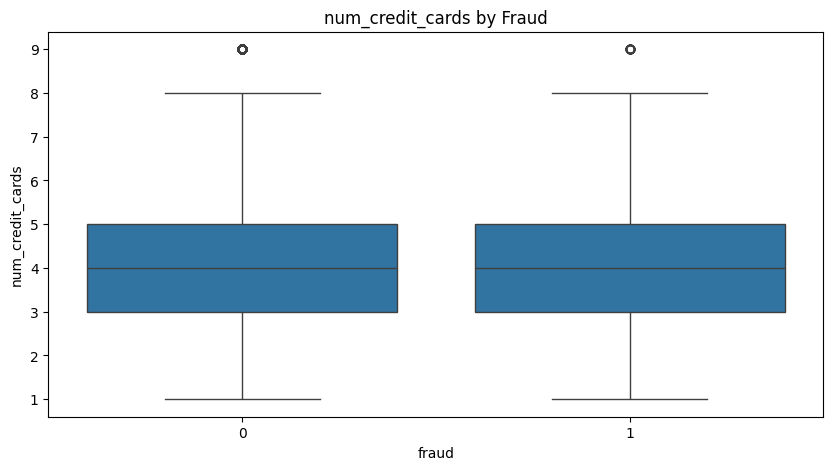

In [10]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="fraud",
    y=col
)

plt.title("num_credit_cards by Fraud")
plt.show()

In [11]:
base = df["fraud"].mean()

tmp = df[[col, "fraud"]].dropna().copy()
tmp["bin"] = pd.qcut(tmp[col], 10, duplicates="drop")

g = tmp.groupby("bin")["fraud"]

credit_score_lift = pd.DataFrame({
    "count": g.size(),
    "fraud_rate": g.mean(),
})

credit_score_lift["lift"] = credit_score_lift["fraud_rate"] / base
credit_score_lift

/tmp/ipykernel_3972462/2932622333.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("bin")["fraud"]


,count,fraud_rate,lift
bin,,,
"(0.999, 2.0]",133694,0.007742,0.717143
"(2.0, 3.0]",136244,0.009909,0.917897
"(3.0, 4.0]",141032,0.012068,1.117942
"(4.0, 5.0]",105227,0.011889,1.101305
"(5.0, 6.0]",50513,0.013977,1.294729
"(6.0, 9.0]",41720,0.012560,1.163495


> fruad 확률 비례 증가 경향

In [12]:
LABEL = "fraud"
col = "num_credit_cards"
def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

rows_uni = []

model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

coef = model.params.get(col, np.nan)
pval = model.pvalues.get(col, np.nan)
or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

lift = top_decile_lift(y, score)

rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,num_credit_cards,0.112277,1.118822,5.264328e-53,0.013336,1.235368,92233


In [13]:
tmp = df[[col, "fraud"]].dropna().copy()
tmp["high_card"] = (tmp[col] > 5).astype(int)

base = tmp["fraud"].mean()

rate_high = tmp.loc[tmp["high_card"] == 1, "fraud"].mean()
rate_low  = tmp.loc[tmp["high_card"] == 0, "fraud"].mean()

pd.DataFrame({
    "fraud_rate_high_card": [rate_high],
    "fraud_rate_low_card": [rate_low],
    "lift_high_card": [rate_high / base],
})

,fraud_rate_high_card,fraud_rate_low_card,lift_high_card
0,0.013336,0.010341,1.235368


In [14]:
df["high_card"] = (df[col]>5).astype(int)

In [15]:
LABEL = "fraud"
col = "high_card"
rows_uni = []

model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

coef = model.params.get(col, np.nan)
pval = model.pvalues.get(col, np.nan)
or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

lift = top_decile_lift(y, score)

rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,high_card,0.257364,1.293516,6.215211e-16,0.013336,1.235368,92233


### Card Meta Layer

**has_chip**

In [16]:
col = "has_chip"

tmp = df[[col, "fraud"]].dropna().copy()
tmp[col] = tmp[col].astype(int)

base = tmp["fraud"].mean()

rate1 = tmp.loc[tmp[col] == 1, "fraud"].mean()
rate0 = tmp.loc[tmp[col] == 0, "fraud"].mean()

pd.DataFrame({
    "p(has_chip=1)": [tmp[col].mean()],
    "fraud_rate|chip=1": [rate1],
    "fraud_rate|chip=0": [rate0],
    "lift|chip=0": [rate0 / base],
})

,p(has_chip=1),fraud_rate|chip=1,fraud_rate|chip=0,lift|chip=0
0,0.913982,0.011011,0.008503,0.787657


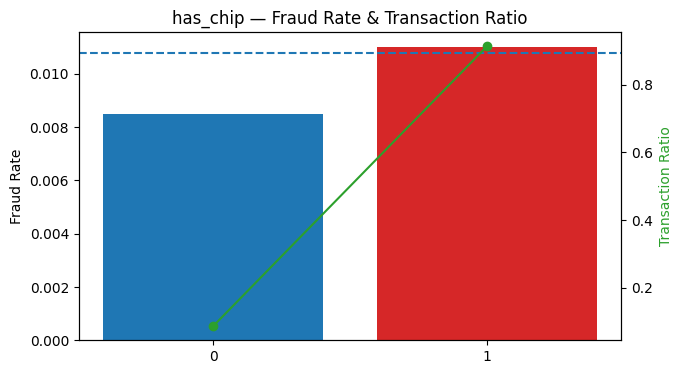

,has_chip,count,fraud_rate,ratio,lift
0,0,52336,0.008503,0.086018,0.787657
1,1,556094,0.011011,0.913982,1.019984


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

col = "has_chip"

tmp = df[[col, "fraud"]].dropna().copy()
tmp[col] = tmp[col].astype(int)

base = tmp["fraud"].mean()

summary = (
    tmp
    .groupby(col)
    .agg(
        count=(col, "size"),
        fraud_rate=("fraud", "mean")
    )
    .reset_index()
)

summary["ratio"] = summary["count"] / summary["count"].sum()
summary["lift"] = summary["fraud_rate"] / base

# 색 지정
bar_colors = ["#d62728" if v == 1 else "#1f77b4" for v in summary[col]]

fig, ax1 = plt.subplots(figsize=(7,4))

x = summary[col].astype(str)

# Fraud rate bar
ax1.bar(x, summary["fraud_rate"], color=bar_colors)
ax1.set_ylabel("Fraud Rate", color="black")
ax1.axhline(base, linestyle="--")

# Transaction ratio line
ax2 = ax1.twinx()
ax2.plot(x, summary["ratio"], marker="o", color="#2ca02c")
ax2.set_ylabel("Transaction Ratio", color="#2ca02c")

plt.title("has_chip — Fraud Rate & Transaction Ratio")
plt.show()

summary

In [18]:
rows_uni = []

model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

coef = model.params.get(col, np.nan)
pval = model.pvalues.get(col, np.nan)
or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

lift = top_decile_lift(y, score)

rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,has_chip,0.261013,1.298245,1.202118e-07,0.011011,1.019984,556094


> 칩이 있는 카드가 오히려 사기 확률이 더 높게 나옴

1.00이 랜덤 수준이니까\
1.02는 사실상 실무적으로 무의미한 수준

**num_cards_issued**

In [19]:
col = "num_cards_issued"

s = pd.to_numeric(df[col], errors="coerce")

pd.DataFrame({
    "count": [s.notna().sum()],
    "missing_rate": [s.isna().mean()],
    "mean": [s.mean()],
    "std": [s.std()],
    "skew": [s.skew()],
    "p01": [s.quantile(0.01)],
    "p50": [s.quantile(0.50)],
    "p99": [s.quantile(0.99)],
    "min": [s.min()],
    "max": [s.max()],
})


,count,missing_rate,mean,std,skew,p01,p50,p99,min,max
0,608430,0.0,1.5114,0.509032,0.059532,1.0,2.0,2.0,1,3


In [20]:
tmp = df[[col, "fraud"]].dropna().copy()
base = tmp["fraud"].mean()

thr = tmp[col].quantile(0.90)
tmp["high_issue"] = (tmp[col] >= thr).astype(int)

rate_high = tmp.loc[tmp["high_issue"] == 1, "fraud"].mean()
rate_low  = tmp.loc[tmp["high_issue"] == 0, "fraud"].mean()

pd.DataFrame({
    "fraud_rate_high_issue": [rate_high],
    "fraud_rate_low_issue": [rate_low],
    "lift_high_issue": [rate_high / base],
})

,fraud_rate_high_issue,fraud_rate_low_issue,lift_high_issue
0,0.010858,0.01073,1.005853


In [21]:
tmp["bin"] = pd.qcut(tmp[col], 10, duplicates="drop")
g = tmp.groupby("bin")["fraud"]

issue_lift = pd.DataFrame({
    "count": g.size(),
    "fraud_rate": g.mean(),
})

issue_lift["lift"] = issue_lift["fraud_rate"] / base
issue_lift

/tmp/ipykernel_3972462/2537588533.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("bin")["fraud"]


,count,fraud_rate,lift
bin,,,
"(0.999, 2.0]",605618,0.010734,0.994395
"(2.0, 3.0]",2812,0.023826,2.207176


In [22]:
LABEL = "fraud"

df["high_issue"] = (df["num_cards_issued"]>2).astype(int)

col = "high_issue"
rows_uni = []

model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

coef = model.params.get(col, np.nan)
pval = model.pvalues.get(col, np.nan)
or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

lift = top_decile_lift(y, score)

rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,high_issue,0.810657,2.249386,6.895914e-11,0.010795,1.0,608430


> lift가 아주 미미 

num_cards_issued > 2인 케이스가 전체의 2,812건(0.46%)에 불과해서, top 10%(60,843건) 안에 이 케이스들이 묻함

"OR은 높지만 support가 0.46%라 전체 랭킹에 기여 불가 → drop"

**months_to_expire**

In [23]:
col = "months_to_expire"

s = pd.to_numeric(df[col], errors="coerce")

pd.DataFrame({
    "min": [s.min()],
    "p01": [s.quantile(0.01)],
    "p50": [s.quantile(0.50)],
    "p99": [s.quantile(0.99)],
    "max": [s.max()],
})

,min,p01,p50,p99,max
0,0,6.0,106.0,169.0,179


In [24]:
tmp = df[[col, "fraud"]].dropna().copy()
base = tmp["fraud"].mean()

tmp["near_expire"] = (tmp[col] <= 3).astype(int)

rate_near = tmp.loc[tmp["near_expire"] == 1, "fraud"].mean()
rate_far  = tmp.loc[tmp["near_expire"] == 0, "fraud"].mean()

pd.DataFrame({
    "fraud_rate_near_expire": [rate_near],
    "fraud_rate_others": [rate_far],
    "lift_near_expire": [rate_near / base],
})

,fraud_rate_near_expire,fraud_rate_others,lift_near_expire
0,0.010783,0.010795,0.998894


In [25]:
tmp["bin"] = pd.qcut(tmp[col], 10, duplicates="drop")
g = tmp.groupby("bin")["fraud"]

expire_lift = pd.DataFrame({
    "count": g.size(),
    "fraud_rate": g.mean(),
})

expire_lift["lift"] = expire_lift["fraud_rate"] / base
expire_lift

/tmp/ipykernel_3972462/136220839.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("bin")["fraud"]


,count,fraud_rate,lift
bin,,,
"(-0.001, 57.0]",61611,0.012433,1.151723
"(57.0, 75.0]",62885,0.011100,1.028219
"(75.0, 87.0]",61484,0.011889,1.101369
"(87.0, 97.0]",61501,0.009642,0.893203
"(97.0, 106.0]",64144,0.009198,0.852066
"(106.0, 114.0]",60216,0.010064,0.932262
"(114.0, 122.0]",57424,0.009212,0.853375
"(122.0, 132.0]",60254,0.010738,0.994709
"(132.0, 146.0]",59946,0.009325,0.863832


In [26]:
df["expire_high"] = (df["months_to_expire"] >= 146).astype(int)

In [27]:
LABEL = "fraud"

col = "expire_high"
rows_uni = []

model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

coef = model.params.get(col, np.nan)
pval = model.pvalues.get(col, np.nan)
or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

lift = top_decile_lift(y, score)

rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,expire_high,0.31327,1.367891,6.836361e-18,0.014181,1.313695,62547


### Categorical Features

is_credit

is_prepaid


In [28]:
LABEL = "fraud"

def credit_prepaid_summary(df):
    base_rate = df[LABEL].mean()

    tmp = (
        df.groupby(["is_credit", "is_prepaid"])[LABEL]
          .agg(["count", "mean"])
          .rename(columns={"mean": "fraud_rate"})
          .reset_index()
    )

    tmp["ratio"] = tmp["count"] / tmp["count"].sum()
    tmp["lift"] = tmp["fraud_rate"] / base_rate

    return tmp

summary_cp = credit_prepaid_summary(df)
summary_cp

,is_credit,is_prepaid,count,fraud_rate,ratio,lift
0,0,0,376487,0.009753,0.618784,0.903504
1,0,1,46172,0.017110,0.075887,1.584988
2,1,0,185771,0.011337,0.305328,1.050166


> is_prepaid 유의

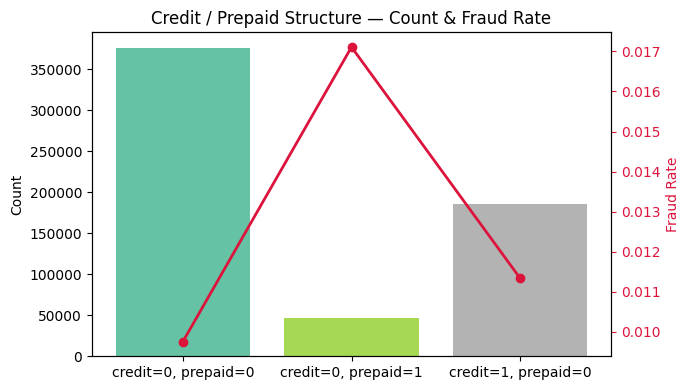

In [ ]:
def credit_prepaid_plot(df):
    tmp = credit_prepaid_summary(df)

    tmp["segment"] = (
        "credit=" + tmp["is_credit"].astype(str)
        + ", prepaid=" + tmp["is_prepaid"].astype(str)
    )

    fig, ax1 = plt.subplots(figsize=(7,4))

    # 색 정의
    bar_colors = plt.cm.Set2(np.linspace(0, 1, len(tmp)))
    line_color = "crimson"

    # Count bar
    ax1.bar(tmp["segment"], tmp["count"], color=bar_colors)
    ax1.set_ylabel("Count", color="black")
    ax1.tick_params(axis="y", colors="black")

    # Fraud rate line
    ax2 = ax1.twinx()
    ax2.plot(
        tmp["segment"],
        tmp["fraud_rate"],
        marker="o",
        color=line_color,
        linewidth=2
    )
    ax2.set_ylabel("Fraud Rate", color=line_color)
    ax2.tick_params(axis="y", colors=line_color)

    plt.xticks(rotation=30)
    plt.title("Credit / Prepaid Structure — Count & Fraud Rate")
    plt.tight_layout()
    plt.show()
    
credit_prepaid_plot(df)

/tmp/ipykernel_3972462/4063181523.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_3972462/4063181523.py:18: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(


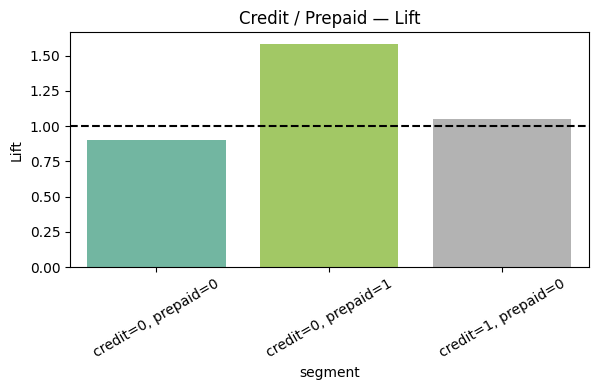

In [ ]:
def credit_prepaid_lift_plot(df):
    tmp = credit_prepaid_summary(df)

    tmp["segment"] = (
        "credit=" + tmp["is_credit"].astype(str)
        + ", prepaid=" + tmp["is_prepaid"].astype(str)
    )

    plt.figure(figsize=(6,4))

    colors = plt.cm.Set2(np.linspace(0, 1, len(tmp)))

    ax = sns.barplot(
        data=tmp,
        x="segment",
        y="lift",
        palette=colors
    )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, color="black")

    ax.set_ylabel("Lift", color="black")
    ax.tick_params(axis="y", colors="black")

    plt.xticks(rotation=30)
    plt.title("Credit / Prepaid — Lift")
    plt.tight_layout()
    plt.show()
credit_prepaid_lift_plot(df)

> prepaid 중요

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

def fraud_rate_test(df, mask1, mask2):
    x1 = df.loc[mask1, "fraud"].sum()
    n1 = mask1.sum()

    x2 = df.loc[mask2, "fraud"].sum()
    n2 = mask2.sum()

    stat, p = proportions_ztest([x1, x2], [n1, n2])
    return stat, p


# prepaid vs credit 
mask_prepaid = (df["is_prepaid"] == 1)
mask_credit  = (df["is_credit"] == 1)

fraud_rate_test(df, mask_prepaid, mask_credit)

(np.float64(9.998593451933823), np.float64(1.5457691876987698e-23))

In [46]:
from statsmodels.stats.proportion import proportion_confint

def wilson_ci(success, n):
    low, high = proportion_confint(success, n, method="wilson")
    return low, high


for seg, g in df.groupby(["is_credit","is_prepaid"]):
    success = g["fraud"].sum()
    n = len(g)
    print(seg, wilson_ci(success, n))

(np.int8(0), np.int8(0)) (0.00944436715698718, 0.010072286768376302)
(np.int8(0), np.int8(1)) (0.015966610874860596, 0.018333607784568783)
(np.int8(1), np.int8(0)) (0.010865122129088613, 0.011828163063434014)


In [47]:
tmp = summary_cp.copy()

tmp["expected_fraud"] = tmp["count"] * tmp["fraud_rate"]
tmp["fraud_share"] = tmp["expected_fraud"] / tmp["expected_fraud"].sum()

tmp

,is_credit,is_prepaid,count,fraud_rate,ratio,lift,expected_fraud,fraud_share
0,0,0,376487,0.009753,0.618784,0.903504,3672.0,0.559074
1,0,1,46172,0.017110,0.075887,1.584988,790.0,0.120280
2,1,0,185771,0.011337,0.305328,1.050166,2106.0,0.320646


In [52]:
COL = ["is_credit", "is_prepaid"]

# 1) util

def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }


# 2) (A) 단변량 검증

rows_uni = []

for col in COL:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)
    lift = top_decile_lift(y, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,is_credit,0.072032,1.074690,6.739010e-03,0.011337,1.050166,185771
1,is_prepaid,0.516736,1.676546,1.347003e-41,0.010795,1.000000,608430


**is_prepaid**

OR ≈ 1.68

p-value ≈ 1e-41

lift ≈ 1.58 (segment 기준)

Wilson CI 완전히 분리

비율 차이 검정 p ≈ 1e-23

→ 통계적으로는 매우 강한 시그널.


*그러나 lift가 낮음 -> 리스크는 높지만, 사기 대부분이 prepaid에서 발생하는 구조는 아니다.*

보조 시그널 및 interaction으로 사용



**is_credit**

OR ≈ 1.07

p ≈ 0.006

lift ≈ 1.05

→ 통계적으로는 유의하지만 실질적 효과는 약함.

---

cb_Visa

cb_Mastercard

cb_Amex

cb_Discover

In [38]:
cb_cols = ["cb_Visa", "cb_Mastercard", "cb_Amex", "cb_Discover"]

def brand_summary(df, label=LABEL, cols=cb_cols):
    base_rate = df[label].mean()
    results = []

    for col in cols:
        tmp = (
            df.groupby(col)[label]
              .agg(count="size", fraud_rate="mean")
              .reset_index()
              .rename(columns={col: "flag"})   # 핵심: 컬럼명 통일
        )
        tmp["brand"] = col
        tmp["lift"] = tmp["fraud_rate"] / base_rate
        results.append(tmp[["brand", "flag", "count", "fraud_rate", "lift"]])

    out = pd.concat(results, ignore_index=True)
    return out.sort_values(["brand", "flag"]).reset_index(drop=True)

summary_brand = brand_summary(df)
summary_brand

,brand,flag,count,fraud_rate,lift
0,cb_Amex,0,563926,0.010734,0.994320
1,cb_Amex,1,44504,0.011572,1.071977
2,cb_Discover,0,594011,0.010628,0.984507
3,cb_Discover,1,14419,0.017685,1.638259
4,cb_Mastercard,0,280876,0.010720,0.993056
5,cb_Mastercard,1,327554,0.010859,1.005955
6,cb_Visa,0,386477,0.011196,1.037148
7,cb_Visa,1,221953,0.010097,0.935316


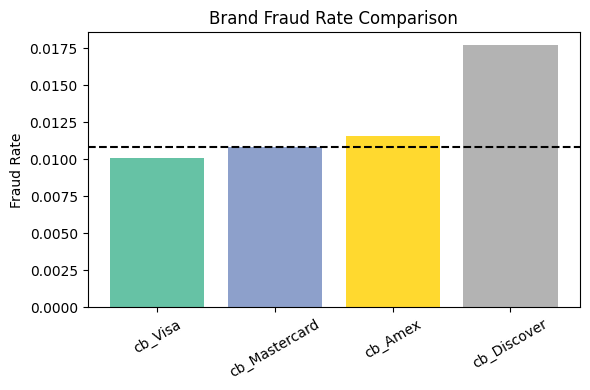

In [ ]:
def brand_fraud_plot(df):
    base_rate = df[LABEL].mean()
    fraud_rates = []

    for col in cb_cols:
        rate = df.loc[df[col] == 1, LABEL].mean()
        fraud_rates.append(rate)

    colors = plt.cm.Set2(np.linspace(0, 1, len(cb_cols)))

    fig, ax = plt.subplots(figsize=(6,4))

    ax.bar(cb_cols, fraud_rates, color=colors)


    ax.axhline(base_rate, linestyle="--", linewidth=1.5, color="black")


    ax.set_ylabel("Fraud Rate", color="black")
    ax.tick_params(axis="y", colors="black")

    ax.set_title("Brand Fraud Rate Comparison")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
brand_fraud_plot(df)

/tmp/ipykernel_3972462/3563841860.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3972462/3563841860.py:13: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


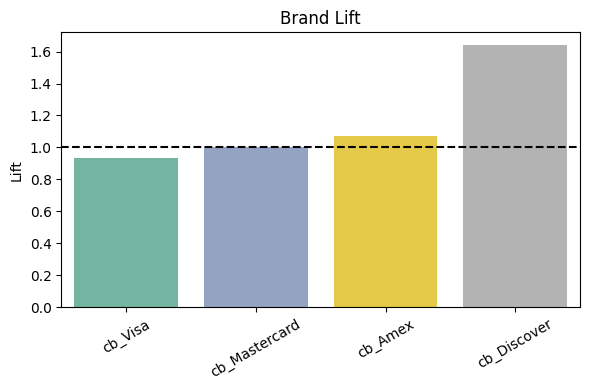

In [42]:
def brand_lift_plot(df):
    base_rate = df[LABEL].mean()
    lifts = []

    for col in cb_cols:
        rate = df.loc[df[col] == 1, LABEL].mean()
        lifts.append(rate / base_rate)

    colors = plt.cm.Set2(np.linspace(0, 1, len(cb_cols)))

    fig, ax = plt.subplots(figsize=(6,4))

    sns.barplot(
        x=cb_cols,
        y=lifts,
        palette=colors,
        ax=ax
    )

    ax.axhline(1.0, linestyle="--", linewidth=1.5, color="black")

    ax.set_ylabel("Lift", color="black")
    ax.tick_params(axis="y", colors="black")

    ax.set_title("Brand Lift")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

brand_lift_plot(df)

In [43]:
brand_share = df[cb_cols].mean().sort_values(ascending=False)
brand_share

cb_Mastercard    0.538359
cb_Visa          0.364796
cb_Amex          0.073146
cb_Discover      0.023699
dtype: float64

> cb_Discover 유의

**Discover**

Lift 1.64

Fraud rate 1.77%

점유율 2.4%

→ 통계적으로는 강함
→ 하지만 volume이 매우 작음
→ 리스크 집중 브랜드

**Amex**

Lift 1.07

약한 양의 신호

점유율 7%

→ 구조적 의미는 크지 않음

**Mastercard**

Lift ≈ 1
→ 사실상 baseline

Visa

Lift < 1
→ 오히려 저위험

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

def brand_vs_others_test(df, brand_col):
    mask_brand = df[brand_col] == 1
    mask_other = df[brand_col] == 0

    x1 = df.loc[mask_brand, "fraud"].sum()
    n1 = mask_brand.sum()

    x2 = df.loc[mask_other, "fraud"].sum()
    n2 = mask_other.sum()

    return proportions_ztest([x1, x2], [n1, n2])

for col in cb_cols:
    print(col, brand_vs_others_test(df, col))

cb_Visa (np.float64(-3.994291062119825), np.float64(6.488811284493823e-05))
cb_Mastercard (np.float64(0.5239852304507884), np.float64(0.6002888125858367))
cb_Amex (np.float64(1.64762533426751), np.float64(0.09942957839238932))
cb_Discover (np.float64(8.102901709476303), np.float64(5.366359331765125e-16))


Visa → 통계적으로 유의한 저위험

Mastercard → 차이 없음

Amex → 약하지만 유의하지 않음 (10% 수준)

Discover → 매우 강한 고위험

In [ ]:
from statsmodels.stats.proportion import proportion_confint

for col in cb_cols:
    for flag in [0,1]:
        g = df[df[col]==flag]
        success = g["fraud"].sum()
        n = len(g)
        low, high = proportion_confint(success, n, method="wilson")
        print(col, flag, (low, high))

cb_Visa 0 (0.010869112636947812, 0.011532622533521645)
cb_Visa 1 (0.009689213439216313, 0.010521208683108513)
cb_Mastercard 0 (0.010345823344140618, 0.011107626029527346)
cb_Mastercard 1 (0.010510045680083237, 0.011219983517570765)
cb_Amex 0 (0.010468043190031716, 0.011005978166053906)
cb_Amex 1 (0.010619667480742643, 0.012608631734289371)
cb_Discover 0 (0.010370129461208232, 0.010891698657098542)
cb_Discover 1 (0.015658578474643296, 0.01996834429836132)


**Visa**

0일 때: (0.01087 ~ 0.01153)

1일 때: (0.00969 ~ 0.01052)

완전히 분리 → 저위험 브랜드 확정

**Mastercard**

CI 거의 완전 겹침 → 의미 없음

**Amex**

약간 상승하지만 CI 겹침 → 통계적으로 불확실

**Discover**

0일 때: (0.01037 ~ 0.01089)

1일 때: (0.01566 ~ 0.01997)

완전 분리 → 구조적 고위험

In [56]:

rows_uni = []

for col in cb_cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)
    lift = top_decile_lift(y, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,cb_Visa,-0.104457,0.900814,6.537260e-05,0.011196,1.037148,386477
1,cb_Mastercard,0.013046,1.013132,6.002913e-01,0.010859,1.005955,327554
2,cb_Amex,0.076049,1.079016,9.951036e-02,0.010795,1.000000,608430
3,cb_Discover,0.516407,1.675995,1.110420e-15,0.010795,1.000000,608430


In [57]:
# 3) (B) Baseline + add-one (다변량 incremental)

base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("\n=== BASELINE ===")
print(base_lift)

rows_inc = []

for col in cb_cols:
    if col in BASELINE:
        rows_inc.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]
    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows_inc.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows_inc)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

print("\n=== Multivariate Add-one vs BASELINE ===")
display(inc_df)



=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663464, 'top_n': 60843}

=== Multivariate Add-one vs BASELINE ===


,added_feature,status,coef,OR,p_value,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,cb_Visa,OK,-0.152357,0.858681,1.083493e-08,0.042651,3.950974,0.000427,0.039586,60843
1,cb_Discover,OK,0.447551,1.564475,4.057915e-11,0.042569,3.943362,0.000345,0.031973,60843
2,cb_Amex,OK,0.069485,1.071956,1.755466e-01,0.042306,3.919001,0.000082,0.007613,60843
3,cb_Mastercard,OK,0.080473,1.083800,2.909247e-03,0.042273,3.915956,0.000049,0.004568,60843


Discover는 통계적으로 확실한 고위험

Visa는 확실한 저위험

Mastercard, Amex는 제거 후보

브랜드는 보조 시그널로 적합

단독 필터로 쓰기엔 위험

Visa: 유지 가치 충분

Discover: 유지 가치 충분

Amex: 제거

Mastercard: 제거

### Continuous Features
months_from_account

years_since_pin_change

years_to_retirement

In [58]:
LABEL = "fraud"
cols = ["months_from_account", "years_since_pin_change", "years_to_retirement"]

In [60]:
def numeric_summary(df, col):
    s = pd.to_numeric(df[col], errors="coerce")
    out = pd.DataFrame({
        "count": [s.notna().sum()],
        "missing_rate": [s.isna().mean()],
        "mean": [s.mean()],
        "std": [s.std()],
        "skew": [s.skew()],
        "p01": [s.quantile(0.01)],
        "p50": [s.quantile(0.50)],
        "p99": [s.quantile(0.99)],
        "min": [s.min()],
        "max": [s.max()],
    })
    return out

for c in cols:
    print(c)
    display(numeric_summary(df, c))

months_from_account


,count,missing_rate,mean,std,skew,p01,p50,p99,min,max
0,608430,0.0,70.985906,47.242727,0.737211,1.0,63.0,194.0,0,299


years_since_pin_change


,count,missing_rate,mean,std,skew,p01,p50,p99,min,max
0,608430,0.0,2.1713,2.18497,0.933909,0.0,2.0,8.0,0,13


years_to_retirement


,count,missing_rate,mean,std,skew,p01,p50,p99,min,max
0,608430,0.0,14.561422,11.725148,0.333099,0.0,14.0,41.0,0,48


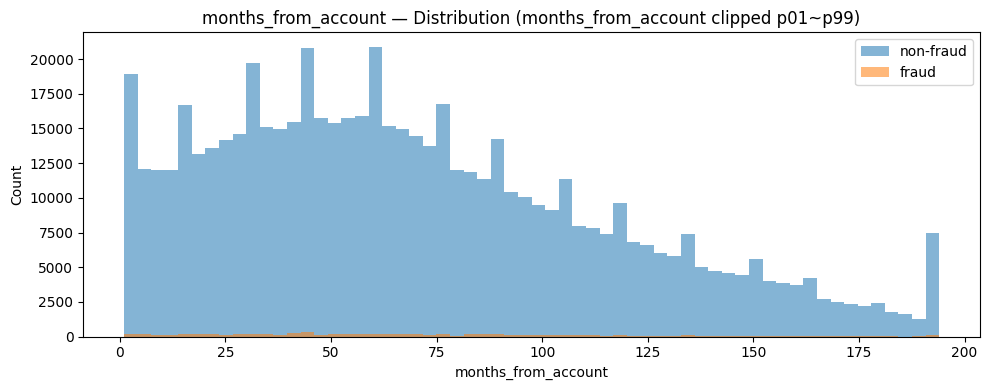

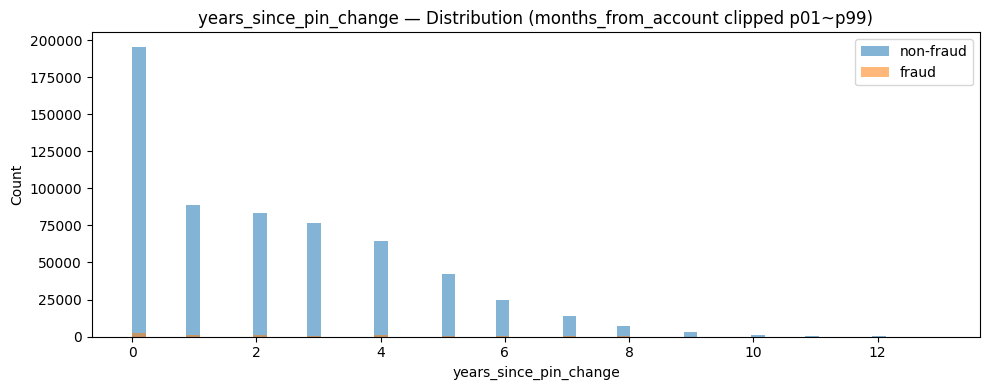

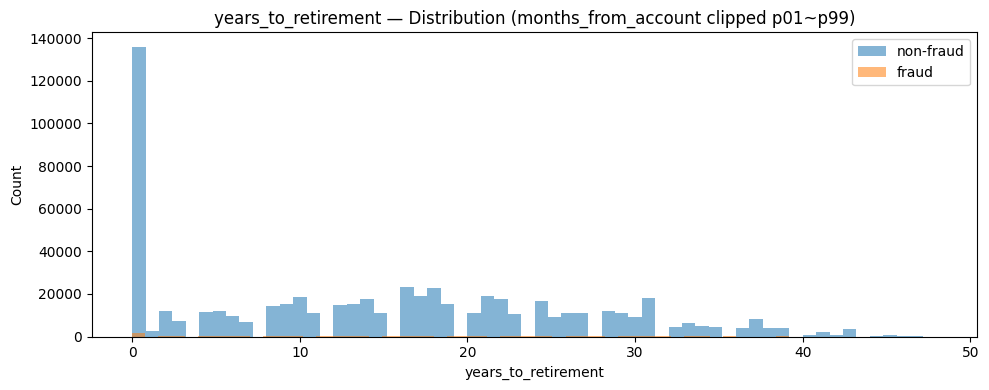

/tmp/ipykernel_3972462/3959450686.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("bin")[LABEL]


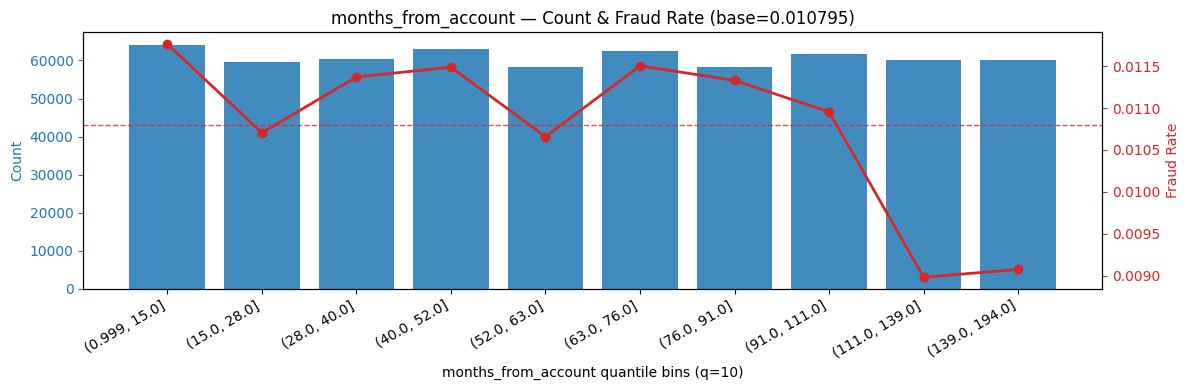

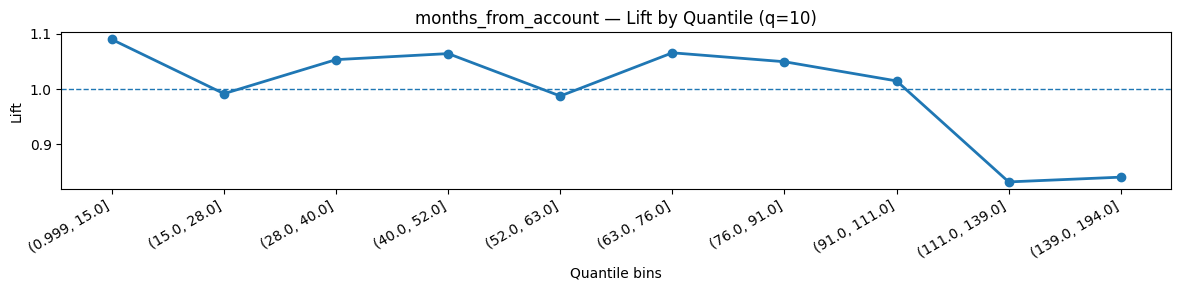

/tmp/ipykernel_3972462/3959450686.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("bin")[LABEL]


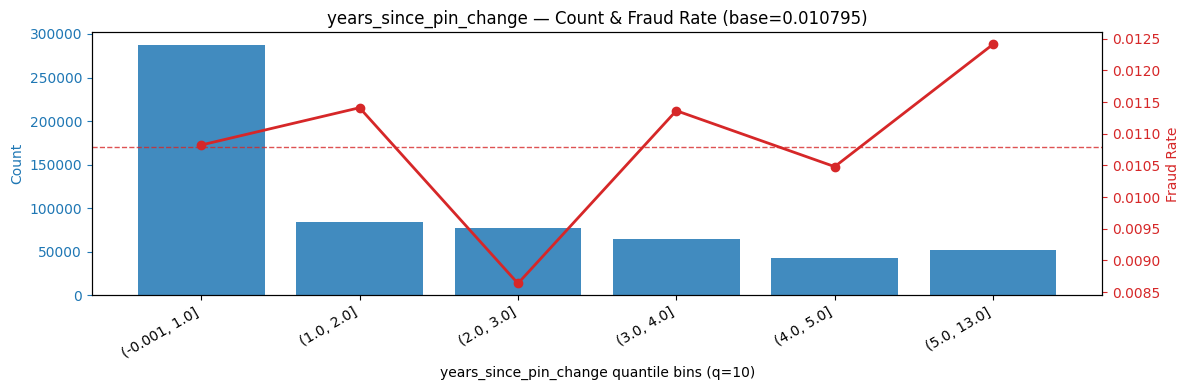

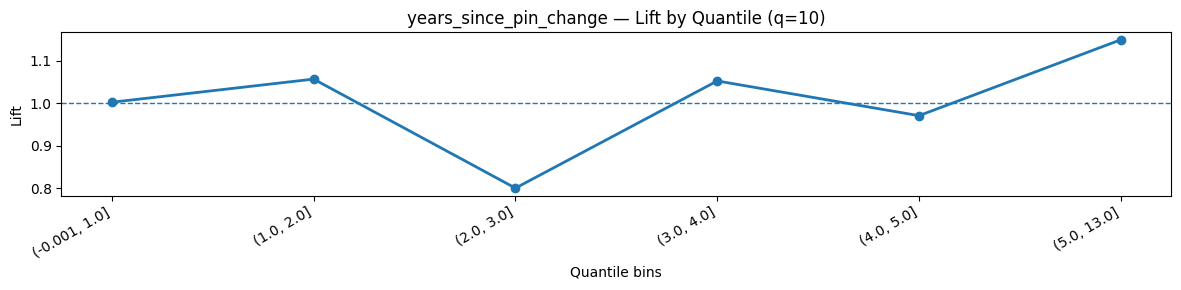

/tmp/ipykernel_3972462/3959450686.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("bin")[LABEL]


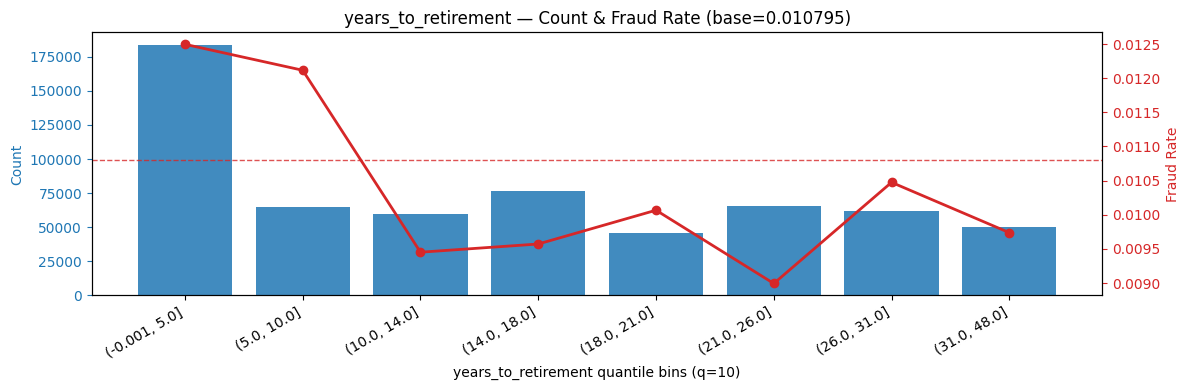

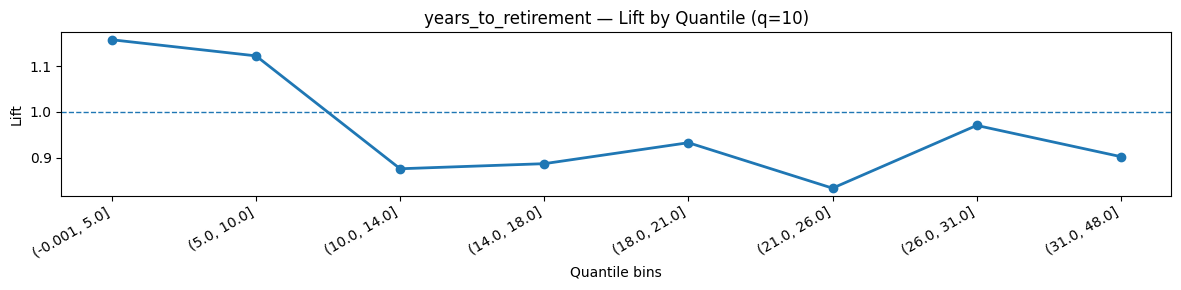

In [ ]:
LABEL = "fraud"
FEATURES = ["months_from_account", "years_since_pin_change", "years_to_retirement"]

def _to_num(s):
    return pd.to_numeric(s, errors="coerce")

def add_clip_col(df, col, q_low=0.01, q_high=0.99):
    s = _to_num(df[col])
    lo = float(s.quantile(q_low))
    hi = float(s.quantile(q_high))
    new_col = f"{col}__clip_{int(q_low*100):02d}_{int(q_high*100):02d}"
    df[new_col] = s.clip(lo, hi)
    return new_col, lo, hi

# months_from_account만 클리핑
mfa_clip_col, mfa_lo, mfa_hi = add_clip_col(df, "months_from_account", 0.01, 0.99)

USE_COL = {
    "months_from_account": mfa_clip_col,
    "years_since_pin_change": "years_since_pin_change",
    "years_to_retirement": "years_to_retirement",
}

# 1) Distribution 비교 (Fraud vs Non-fraud)

def plot_hist_compare(df, col, bins=60):
    c = USE_COL[col]
    s0 = _to_num(df.loc[df[LABEL] == 0, c]).dropna()
    s1 = _to_num(df.loc[df[LABEL] == 1, c]).dropna()

    plt.figure(figsize=(10, 4))
    plt.hist(s0, bins=bins, alpha=0.55, label="non-fraud")
    plt.hist(s1, bins=bins, alpha=0.55, label="fraud")
    plt.title(f"{col} — Distribution (months_from_account clipped p01~p99)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

for c in FEATURES:
    plot_hist_compare(df, c, bins=60)


# 2) Quantile Risk Curve: Count + Fraud rate 

def quantile_table(df, col, q=10):
    c = USE_COL[col]
    tmp = df[[c, LABEL]].copy()
    tmp[c] = _to_num(tmp[c])
    tmp = tmp.dropna(subset=[c, LABEL])

    tmp["bin"] = pd.qcut(tmp[c], q=q, duplicates="drop")
    g = (
        tmp.groupby("bin")[LABEL]
           .agg(["count", "mean"])
           .rename(columns={"mean": "fraud_rate"})
           .reset_index()
    )
    base = float(tmp[LABEL].mean())
    g["lift"] = g["fraud_rate"] / base
    return g, base

def plot_quantile_dual_axis(df, col, q=10):
    g, base = quantile_table(df, col, q=q)

    x = np.arange(len(g))
    count_color = "tab:blue"
    rate_color  = "tab:red"

    fig, ax1 = plt.subplots(figsize=(12, 4))

    ax1.bar(x, g["count"].values, alpha=0.85, color=count_color)
    ax1.set_ylabel("Count", color=count_color)
    ax1.tick_params(axis="y", colors=count_color)

    ax1.set_xlabel(f"{col} quantile bins (q={q})")
    ax1.set_xticks(x)
    ax1.set_xticklabels([str(b) for b in g["bin"]], rotation=30, ha="right")

    ax2 = ax1.twinx()
    ax2.plot(x, g["fraud_rate"].values, marker="o", color=rate_color, linewidth=2)
    ax2.axhline(base, color=rate_color, linestyle="--", linewidth=1, alpha=0.8)
    ax2.set_ylabel("Fraud Rate", color=rate_color)
    ax2.tick_params(axis="y", colors=rate_color)

    plt.title(f"{col} — Count & Fraud Rate (base={base:.6f})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 3))
    plt.plot(x, g["lift"].values, marker="o", linewidth=2)
    plt.axhline(1.0, linestyle="--", linewidth=1)
    plt.xticks(x, [str(b) for b in g["bin"]], rotation=30, ha="right")
    plt.title(f"{col} — Lift by Quantile (q={q})")
    plt.xlabel("Quantile bins")
    plt.ylabel("Lift")
    plt.tight_layout()
    plt.show()

for c in FEATURES:
    plot_quantile_dual_axis(df, c, q=10)

**months_from_account**

*관찰*

초반 구간(0~15개월) lift ≈ 1.09

중간 구간은 거의 baseline

111개월 이상에서 급격히 하락 (≈0.83)

*해석*

이 변수는 단조(monotonic) 구조가 아니다.

신규 계정 → 약간 위험

중간 구간 → 평균

장기 계정 → 명확한 저위험

즉,

“신규 위험”이라기보다는
“장기 계정 안전” 신호에 더 가깝다.

**years_since_pin_change**


*관찰*

2~3년 구간 lift ≈ 0.8 (저위험)

5년 이상에서 lift ≈ 1.15 (고위험)

*구조*

U-shape 경향.

PIN 너무 최근 변경 → baseline

2~3년 변경 → 안정

오랫동안 변경 안 함 → 위험 증가

*해석*

이 변수는 단순 선형이 아니라:

“오래 PIN 안 바꾼 계정” 리스크 가능성

이건 보안적 해석과 일치

**years_to_retirement**

*관찰*

0~10년 남음 → lift 1.1 이상

10~25년 구간 → 저위험

25년 이상 → baseline 근처

*구조*

이건 거의 연령대 proxy 변수다.

은퇴 가까운 연령층에서 약간 위험 증가.

하지만 lift 최대 1.15 수준.

*해석*

독립 강한 시그널은 아님.

다른 demographic 변수에 흡수될 가능성 높음.

months_from_account → 장기 계정 안전 신호

years_since_pin_change → 오래 PIN 미변경 위험 신호

years_to_retirement → 약한 demographic 보조 신호

In [63]:
def scan_threshold_lowrisk(df, col, min_support=0.05):
    base = df["fraud"].mean()
    s = df[col]

    results = []

    for t in np.linspace(s.quantile(0.5), s.quantile(0.99), 20):
        flag = (s >= t).astype(int)
        support = flag.mean()
        if support < min_support:
            continue

        rate = df.loc[flag==1, "fraud"].mean()
        lift = rate / base

        results.append((t, support, rate, lift))

    out = pd.DataFrame(results, columns=["threshold","support","fraud_rate","lift"])
    return out.sort_values("lift")

scan_threshold_lowrisk(df, "months_from_account").head()

,threshold,support,fraud_rate,lift
8,118.157895,0.168932,0.008805,0.815652
12,145.736842,0.083334,0.008915,0.825814
9,125.052632,0.142381,0.008935,0.827666
13,152.631579,0.066727,0.008966,0.830546
7,111.263158,0.197717,0.009028,0.836282


In [64]:
def scan_threshold_highrisk(df, col, min_support=0.03):
    base = df["fraud"].mean()
    s = df[col]

    results = []

    for t in sorted(s.unique()):
        flag = (s >= t).astype(int)
        support = flag.mean()
        if support < min_support:
            continue

        rate = df.loc[flag==1, "fraud"].mean()
        lift = rate / base

        results.append((t, support, rate, lift))

    out = pd.DataFrame(results, columns=["threshold","support","fraud_rate","lift"])
    return out.sort_values("lift", ascending=False)

scan_threshold_highrisk(df, "years_since_pin_change").head()

,threshold,support,fraud_rate,lift
7,7,0.043213,0.014339,1.328297
6,6,0.084743,0.012413,1.149859
5,5,0.155155,0.011536,1.068633
4,4,0.262323,0.011466,1.062141
0,0,1.000000,0.010795,1.000000


In [65]:
def retirement_scan(df):
    base = df["fraud"].mean()
    s = df["years_to_retirement"]

    results = []

    for t in [5, 8, 10, 12, 15]:
        flag = (s <= t).astype(int)
        support = flag.mean()
        rate = df.loc[flag==1, "fraud"].mean()
        lift = rate / base

        results.append((t, support, rate, lift))

    return pd.DataFrame(results, columns=["threshold","support","fraud_rate","lift"])

retirement_scan(df)

,threshold,support,fraud_rate,lift
0,5,0.301977,0.012496,1.157616
1,8,0.352759,0.012925,1.197279
2,10,0.408599,0.012397,1.148423
3,12,0.451322,0.012101,1.121012
4,15,0.524304,0.011693,1.083161


In [66]:
df["long_tenure_safe"] = (df["months_from_account"] >= 115).astype("int8")

df["pin_old_flag"] = (df["years_since_pin_change"] >= 6).astype("int8")

df["near_retirement_flag"] = (df["years_to_retirement"] <= 8).astype("int8")

In [68]:
# 3) (B) Baseline + add-one (다변량 incremental)

cols = FEATURES + ["long_tenure_safe", "pin_old_flag", "near_retirement_flag"]

base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("\n=== BASELINE ===")
print(base_lift)

rows_inc = []

for col in cols:
    if col in BASELINE:
        rows_inc.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]
    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows_inc.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows_inc)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

print("\n=== Multivariate Add-one vs BASELINE ===")
display(inc_df)



=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663464, 'top_n': 60843}

=== Multivariate Add-one vs BASELINE ===


,added_feature,status,coef,OR,p_value,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,years_since_pin_change,OK,0.026169,1.026515,3.196581e-06,0.042700,3.955542,0.000477,0.044153,60843
1,near_retirement_flag,OK,0.335562,1.398727,8.405438e-15,0.042601,3.946407,0.000378,0.035018,60843
2,pin_old_flag,OK,0.211059,1.234985,5.557766e-07,0.042503,3.937272,0.000279,0.025883,60843
3,months_from_account,OK,-0.001018,0.998983,1.975231e-04,0.042256,3.914434,0.000033,0.003045,60843
4,years_to_retirement,OK,-0.005431,0.994584,3.084389e-02,0.042240,3.912911,0.000016,0.001523,60843
5,long_tenure_safe,OK,-0.189549,0.827333,4.917958e-08,0.041681,3.861145,-0.000542,-0.050244,60843


유지:

years_since_pin_change (연속형)
near_retirement_flag

제거:

months_from_account
long_tenure_safe
pin_old_flag
years_to_retirement (연속형)

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# VIF 확인할 컬럼 목록 (Stage1 최종 후보들)
cols_for_vif = [
    "years_since_pin_change",
    "near_retirement_flag",
]

X = df[cols_for_vif].copy()
X = X.replace([np.inf, -np.inf], np.nan).dropna()
X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["feature"] = X.columns
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_df.sort_values("VIF", ascending=False)

,feature,VIF
0,const,2.452519
1,years_since_pin_change,1.003358
2,near_retirement_flag,1.003358
